
=== Performance Tables (test/MFO) ===

--- Fmax (Higher is better) ---
                                                         Model              Checkpoint      Fmax
0           20251202_010908_D1_2layerGNN_STRINGDB_CONTACT_ATTR  checkpoint_epoch_4_MFO  0.621104
1                   20251118_143647_D1_2layerGNN_STRINGDB_ATTR  checkpoint_epoch_6_MFO  0.616682
2                20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR   checkpoint_latest_MFO  0.616650
3                         20251119_001551_D1_2layerGNN_CONTACT   checkpoint_latest_MFO  0.614989
4                    20251118_150705_D1_2layerGNN_CONTACT_ATTR  checkpoint_epoch_6_MFO  0.613588
5              20251121_055839_D1_2layerGNN_NOSYS_CONTACT_ATTR   checkpoint_latest_MFO  0.612883
6  20251119_233156_D1_2layerGNN_default_CONTACT_ATTR_SWISS_CUR  checkpoint_epoch_1_MFO  0.595695
7                                 20251204_093632_D1_2layerGNN  checkpoint_epoch_5_MFO  0.583405
8               20251118_135639_D1_2layerGNN_default_SW

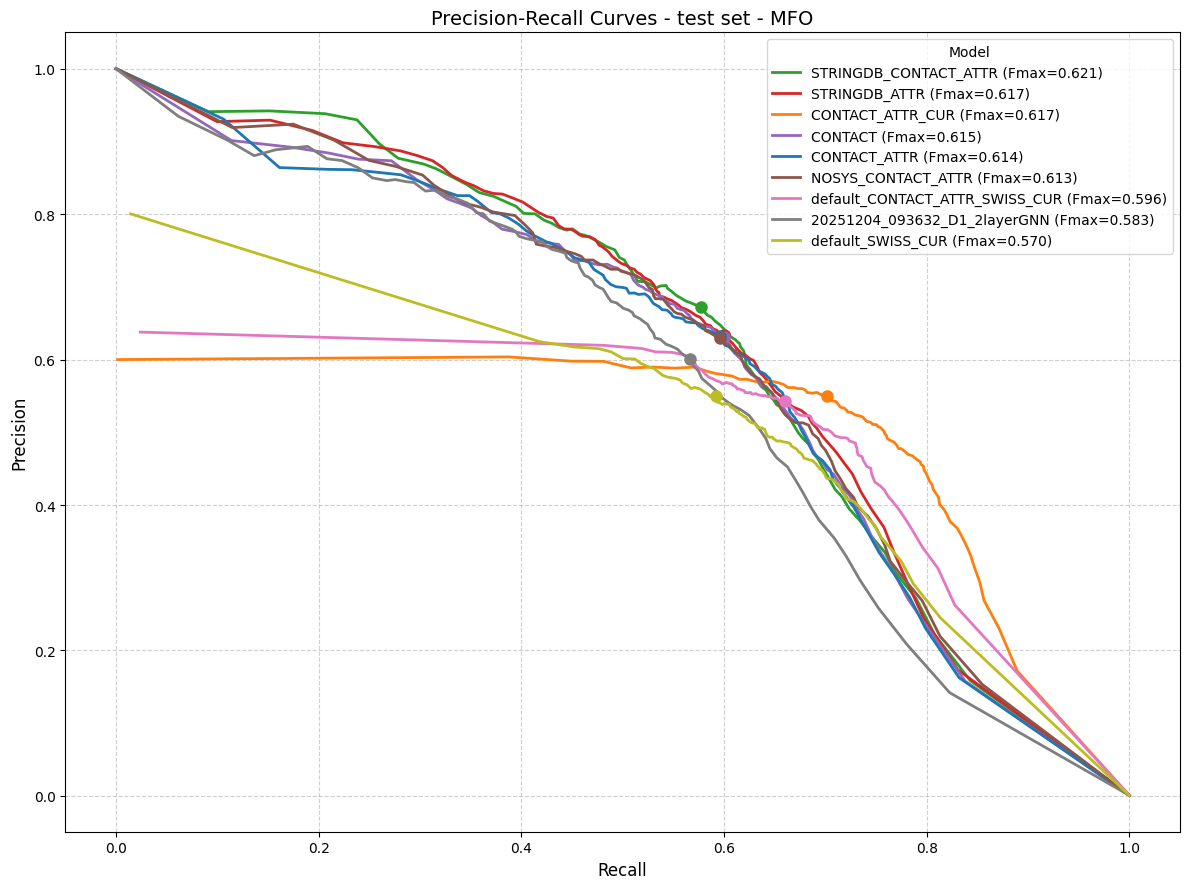

In [2]:
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configuration
GLOBAL_EVAL_DIR = "/home/atoffano/PFP_layer/results/D1/global_eval"
SPLIT = "test"
SUBONTOLOGY = "MFO"

def load_data():
    all_data = []
    
    if not os.path.exists(GLOBAL_EVAL_DIR):
        print(f"Error: Directory {GLOBAL_EVAL_DIR} not found.")
        return pd.DataFrame()

    # Traverse: model / checkpoint / split / subontology / beprof-eval / beprof_eval_results.pkl
    # Get all model directories
    try:
        models = [d for d in os.listdir(GLOBAL_EVAL_DIR) if os.path.isdir(os.path.join(GLOBAL_EVAL_DIR, d))]
    except OSError as e:
        print(f"Error accessing {GLOBAL_EVAL_DIR}: {e}")
        return pd.DataFrame()
    
    for model in models:
        model_dir = os.path.join(GLOBAL_EVAL_DIR, model)
        checkpoints = [d for d in os.listdir(model_dir) if os.path.isdir(os.path.join(model_dir, d))]
        
        for ckpt in checkpoints:
            # Construct path to the specific result file
            result_path = os.path.join(
                model_dir, 
                ckpt, 
                SPLIT, 
                SUBONTOLOGY, 
                "beprof-eval", 
                "beprof_eval_results.pkl"
            )
            
            if os.path.exists(result_path):
                try:
                    with open(result_path, 'rb') as f:
                        res = pickle.load(f)
                    
                    all_data.append({
                        'Model': model,
                        'Checkpoint': ckpt,
                        'Fmax': res.get('result_fmax', 0.0),
                        'Smin': res.get('result_smin', float('inf')),
                        'Precisions': res.get('precisions'),
                        'Recalls': res.get('recalls')
                    })
                except Exception as e:
                    print(f"Failed to load {result_path}: {e}")
    
    return pd.DataFrame(all_data)

def main():
    df = load_data()
    
    if df.empty:
        print("No data found. Check your GLOBAL_EVAL_DIR path and ensure evaluations have run.")
        return

    # Select best checkpoint per model based on Fmax
    # Sort by Fmax descending so the first occurrence of a model is its best
    df_best = df.sort_values('Fmax', ascending=False).drop_duplicates(subset='Model', keep='first')
    
    # 1. Tables
    print(f"\n=== Performance Tables ({SPLIT}/{SUBONTOLOGY}) ===")
    
    print("\n--- Fmax (Higher is better) ---")
    fmax_table = df_best[['Model', 'Checkpoint', 'Fmax']].sort_values('Fmax', ascending=False).reset_index(drop=True)
    print(fmax_table.to_string())
    
    print("\n--- Smin (Lower is better) ---")
    smin_table = df_best[['Model', 'Checkpoint', 'Smin']].sort_values('Smin', ascending=True).reset_index(drop=True)
    print(smin_table.to_string())

    # 2. Plotting
    plt.figure(figsize=(12, 9))
    
    # Custom color mapping
    # Custom color mapping with increased saturation
    from matplotlib.colors import to_rgba

    custom_colors = {
        "20251118_150705_D1_2layerGNN_CONTACT_ATTR": to_rgba("tab:blue", alpha=1.0),
        "20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR": to_rgba("tab:orange", alpha=1.0)
    }    
    # Get tab10 colormap
    cmap = plt.get_cmap('tab10')
    # Start index for other models (skip 0=blue, 1=orange to avoid confusion)
    color_idx = 2
    
    # Plot curves for best models
    for _, row in df_best.iterrows():
        recalls = row['Recalls']
        precisions = row['Precisions']
        model_name = row['Model']
        
        if recalls is not None and precisions is not None:
            # Determine color
            if model_name in custom_colors:
                color = custom_colors[model_name]
            else:
                color = cmap(color_idx % 10)
                color_idx += 1

            # Label with Fmax
            label = f"{row['Model']} (Fmax={row['Fmax']:.3f})"
            line, = plt.plot(recalls, precisions, label=label, linewidth=2, color=color)

            # Calculate F-score for each point to find the location of Fmax
            r_arr = np.array(recalls)
            p_arr = np.array(precisions)
            
            # Compute F-scores safely
            with np.errstate(divide='ignore', invalid='ignore'):
                f_scores = 2 * p_arr * r_arr / (p_arr + r_arr)
            
            # Handle NaNs (0/0) by replacing with 0
            f_scores = np.nan_to_num(f_scores)
            
            # Find the index of the maximum F-score
            best_idx = np.argmax(f_scores)
            
            # Plot the dot at Fmax location using the same color as the line
            plt.plot(r_arr[best_idx], p_arr[best_idx], 'o', color=line.get_color(), markersize=8)

    plt.xlabel('Recall', fontsize=12)

    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Precision-Recall Curves - {SPLIT} set - {SUBONTOLOGY}', fontsize=14)
    
    # Legend inside the figure (loc='best' automatically finds a spot with minimal overlap)
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', loc='best', fontsize=10)
    
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    
if __name__ == "__main__":
    main()

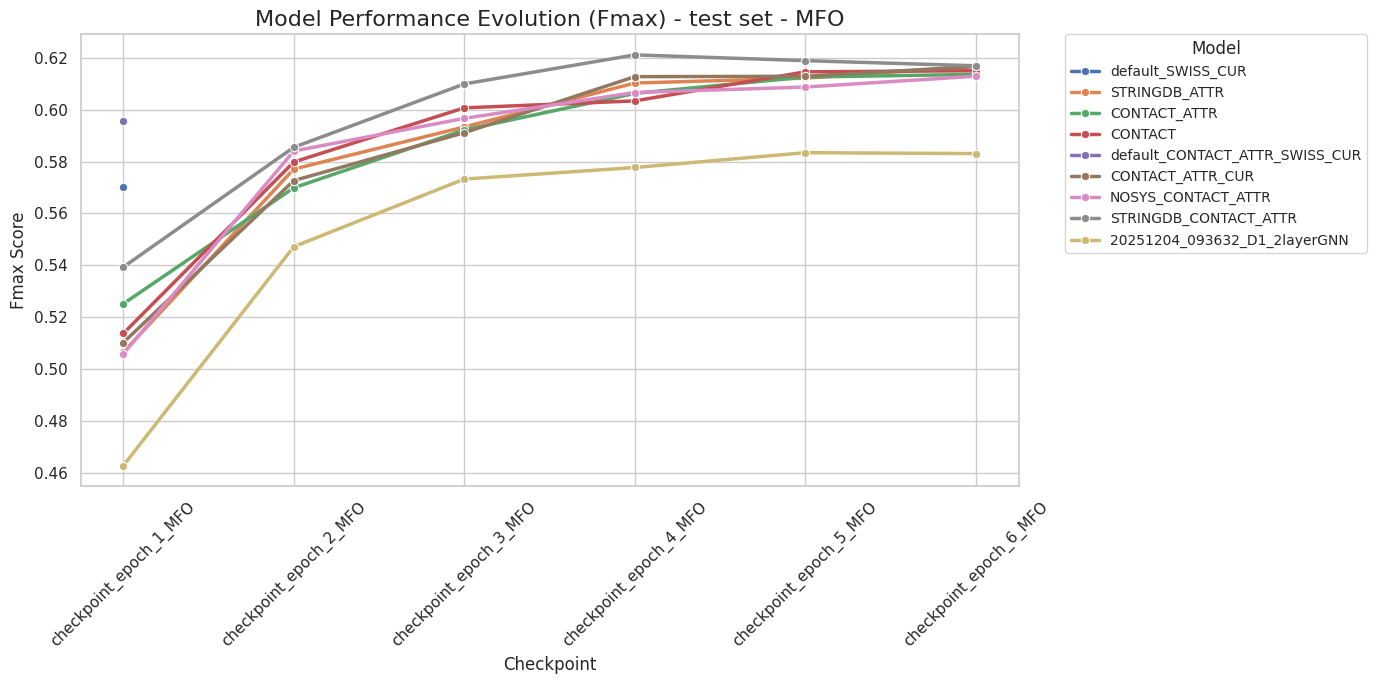

In [3]:
import seaborn as sns
df_filtered = load_data()

# Filter out 'checkpoint_latest' from the dataframe
df_filtered = df_filtered[df_filtered['Checkpoint'] != 'checkpoint_latest_MFO']
df_filtered = df_filtered.sort_values(['Model', 'Checkpoint'])
if not df_filtered.empty:
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Plot using seaborn lineplot
    sns.lineplot(
        data=df_filtered, 
        x='Checkpoint', 
        y='Fmax', 
        hue='Model', 
        marker='o',
        linewidth=2.5
    )

    plt.title(f'Model Performance Evolution (Fmax) - {SPLIT} set - {SUBONTOLOGY}', fontsize=16)
    plt.xlabel('Checkpoint', fontsize=12)
    plt.ylabel('Fmax Score', fontsize=12)
    plt.xticks(rotation=45)
    
    # Remove 'GNN_' and all that came befor from legend labels for clarity
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot after filtering.")

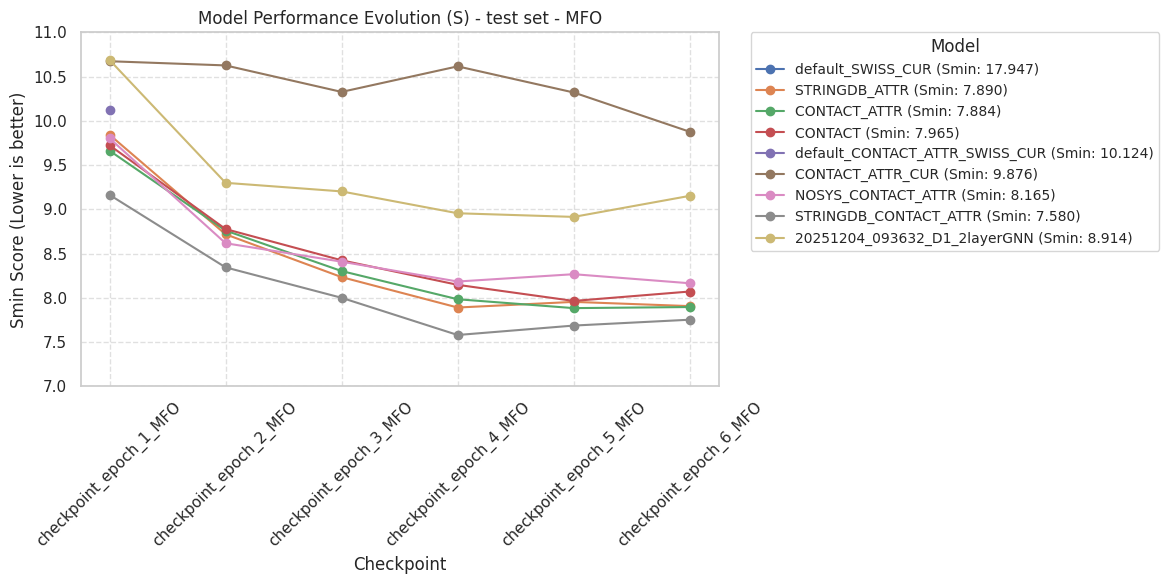

In [4]:
if not df_filtered.empty:
    plt.figure(figsize=(12, 6))

    # Get unique models (already defined as 'models' in previous cell, but safe to reuse from df_filtered)
    models = df_filtered['Model'].unique()

    for model in models:
        model_data = df_filtered[df_filtered['Model'] == model]
        
        # Plot Smin evolution
        # Smin is "lower is better", so we highlight the minimum value
        plt.plot(model_data['Checkpoint'], model_data['Smin'], marker='o', label=f"{model} (Smin: {model_data['Smin'].min():.3f})")

    plt.xlabel('Checkpoint')
    plt.ylabel('Smin Score (Lower is better)')
    plt.title(f'Model Performance Evolution (S) - {SPLIT} set - {SUBONTOLOGY}')
    plt.xticks(rotation=45)
    plt.ylim(7,11)
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("No data available to plot evolution.")


=== CAFA Performance Tables (test/MFO) ===

--- Fmax (Standard) ---
                                                         Model              Checkpoint   Fmax
0           20251202_010908_D1_2layerGNN_STRINGDB_CONTACT_ATTR  checkpoint_epoch_4_MFO  0.678
1                   20251118_143647_D1_2layerGNN_STRINGDB_ATTR   checkpoint_latest_MFO  0.672
2                         20251119_001551_D1_2layerGNN_CONTACT  checkpoint_epoch_5_MFO  0.670
3                    20251118_150705_D1_2layerGNN_CONTACT_ATTR   checkpoint_latest_MFO  0.668
4              20251121_055839_D1_2layerGNN_NOSYS_CONTACT_ATTR   checkpoint_latest_MFO  0.666
5                20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR   checkpoint_latest_MFO  0.657
6                                 20251204_093632_D1_2layerGNN  checkpoint_epoch_5_MFO  0.640
7  20251119_233156_D1_2layerGNN_default_CONTACT_ATTR_SWISS_CUR   checkpoint_latest_MFO  0.639
8               20251118_135639_D1_2layerGNN_default_SWISS_CUR  checkpoint_epoch_1_MF

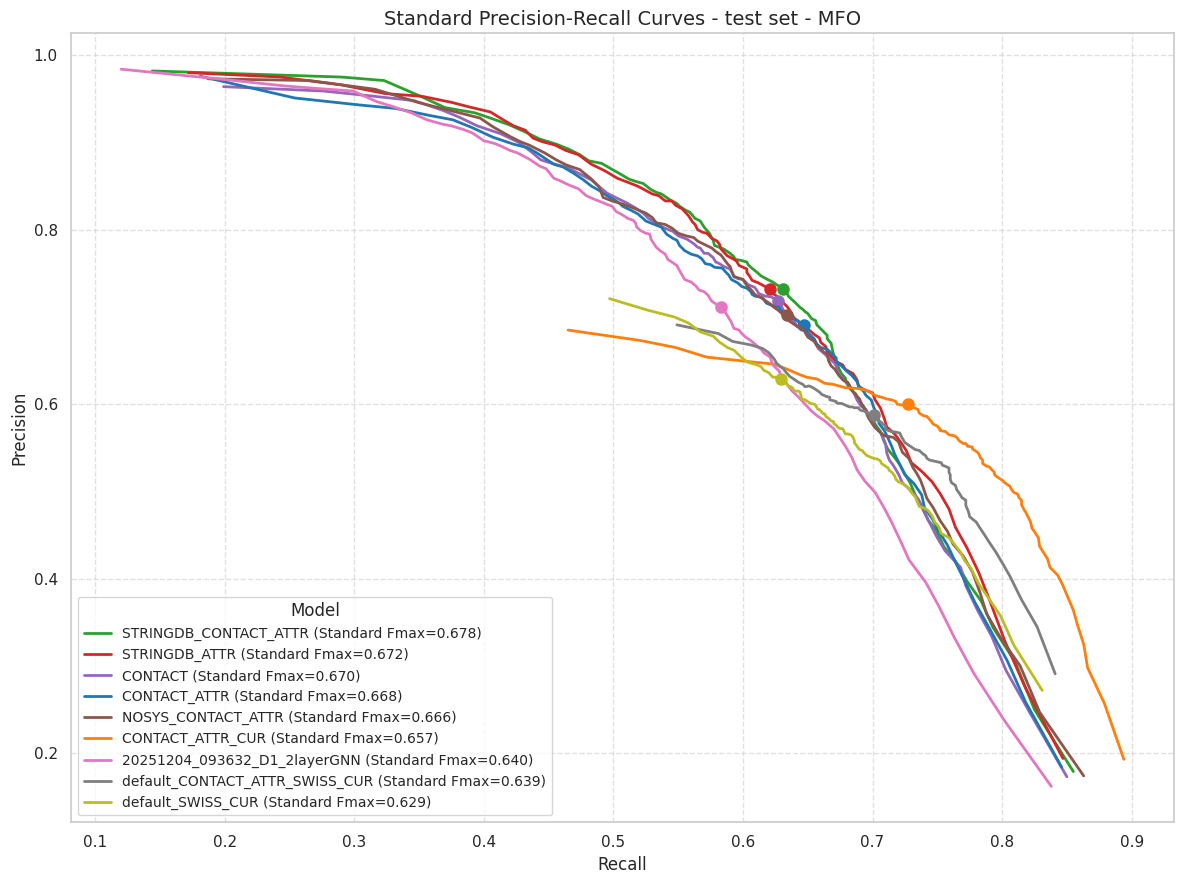


--- Fmax (Weighted) ---
                                                         Model              Checkpoint  Fmax_w
0                                 20251204_093632_D1_2layerGNN  checkpoint_epoch_6_MFO   0.544
1               20251118_135639_D1_2layerGNN_default_SWISS_CUR   checkpoint_latest_MFO     NaN
2                   20251118_143647_D1_2layerGNN_STRINGDB_ATTR  checkpoint_epoch_6_MFO     NaN
3           20251202_010908_D1_2layerGNN_STRINGDB_CONTACT_ATTR  checkpoint_epoch_6_MFO     NaN
4              20251121_055839_D1_2layerGNN_NOSYS_CONTACT_ATTR  checkpoint_epoch_6_MFO     NaN
5                20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR  checkpoint_epoch_6_MFO     NaN
6                         20251119_001551_D1_2layerGNN_CONTACT  checkpoint_epoch_6_MFO     NaN
7  20251119_233156_D1_2layerGNN_default_CONTACT_ATTR_SWISS_CUR   checkpoint_latest_MFO     NaN
8                    20251118_150705_D1_2layerGNN_CONTACT_ATTR  checkpoint_epoch_6_MFO     NaN


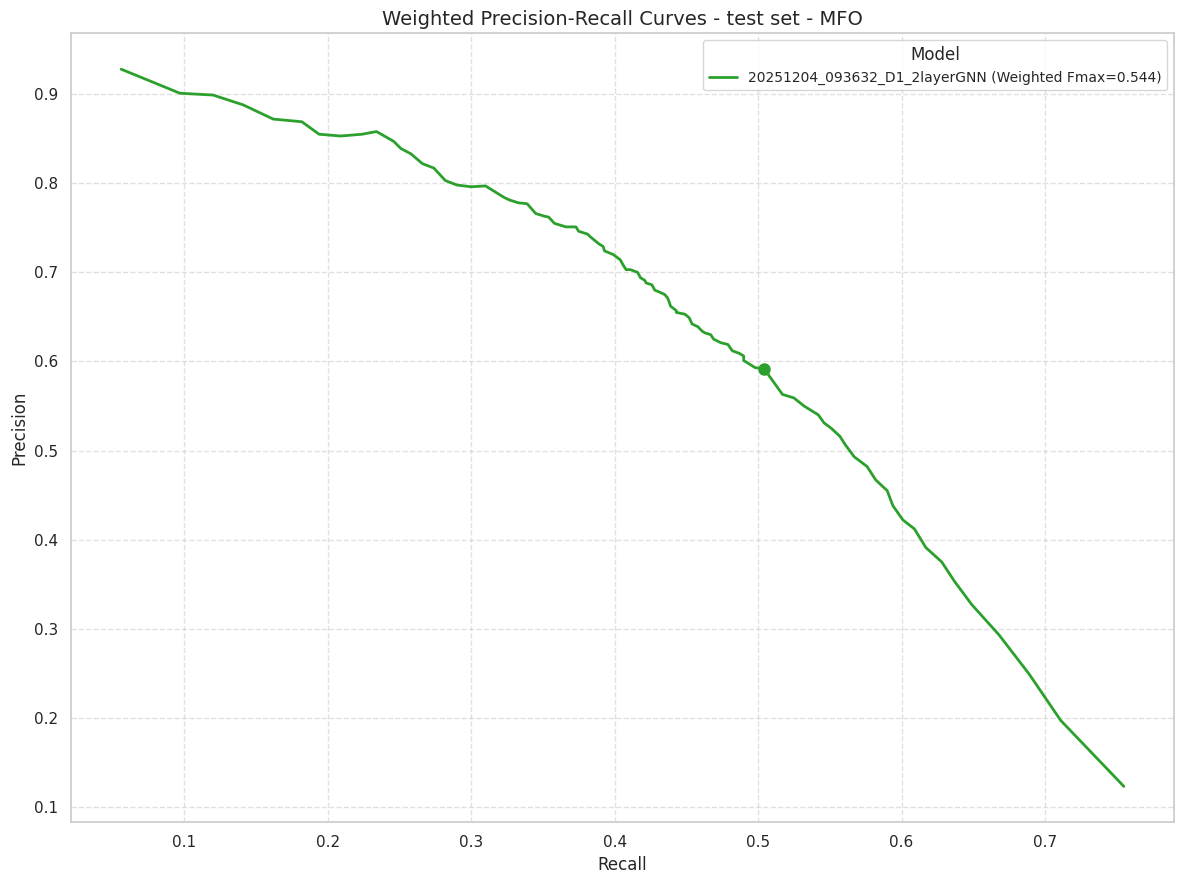

In [5]:
from matplotlib.colors import to_rgba

def load_cafa_tsv_data():
    data_list = []
    
    if not os.path.exists(GLOBAL_EVAL_DIR):
        print(f"Directory not found: {GLOBAL_EVAL_DIR}")
        return pd.DataFrame()

    try:
        models_dirs = [d for d in os.listdir(GLOBAL_EVAL_DIR) if os.path.isdir(os.path.join(GLOBAL_EVAL_DIR, d))]
    except Exception as e:
        print(e)
        return pd.DataFrame()

    for model in models_dirs:
        model_path = os.path.join(GLOBAL_EVAL_DIR, model)
        checkpoints = [d for d in os.listdir(model_path) if os.path.isdir(os.path.join(model_path, d))]
        
        for ckpt in checkpoints:
            # Path to evaluation_all.tsv
            tsv_file = os.path.join(model_path, ckpt, SPLIT, SUBONTOLOGY, "cafa-eval", "evaluation_all.tsv")
            
            if os.path.exists(tsv_file):
                try:
                    # Read TSV
                    df_res = pd.read_csv(tsv_file, sep='\t')
                    
                    # Extract Standard Metrics
                    # Fmax is max of 'f' column
                    fmax = df_res['f'].max() if 'f' in df_res.columns else 0.0
                    # Smin is min of 's' column
                    smin = df_res['s'].min() if 's' in df_res.columns else float('inf')
                    
                    # Arrays for plotting
                    # PR curve: x=Recall (rc), y=Precision (pr)
                    precisions = df_res['pr'].values if 'pr' in df_res.columns else []
                    recalls = df_res['rc'].values if 'rc' in df_res.columns else []
                    
                    # Extract Weighted Metrics if available
                    fmax_w = df_res['f_w'].max() if 'f_w' in df_res.columns else np.nan
                    precisions_w = df_res['pr_w'].values if 'pr_w' in df_res.columns else []
                    recalls_w = df_res['rc_w'].values if 'rc_w' in df_res.columns else []

                    data_list.append({
                        'Model': model,
                        'Checkpoint': ckpt,
                        'Fmax': fmax,
                        'Smin': smin,
                        'Precisions': precisions,
                        'Recalls': recalls,
                        'Fmax_w': fmax_w,
                        'Precisions_w': precisions_w,
                        'Recalls_w': recalls_w
                    })
                except Exception as e:
                    print(f"Failed to read {tsv_file}: {e}")

    return pd.DataFrame(data_list)

def plot_pr_curves(df_best, metric_type='Standard'):
    plt.figure(figsize=(12, 9))
    
    custom_colors = {
        "20251118_150705_D1_2layerGNN_CONTACT_ATTR": to_rgba("tab:blue", alpha=1.0),
        "20251121_055839_D1_2layerGNN_CONTACT_ATTR_CUR": to_rgba("tab:orange", alpha=1.0)
    }
    cmap = plt.get_cmap('tab10')
    color_idx = 2
    
    col_p = 'Precisions' if metric_type == 'Standard' else 'Precisions_w'
    col_r = 'Recalls' if metric_type == 'Standard' else 'Recalls_w'
    col_f = 'Fmax' if metric_type == 'Standard' else 'Fmax_w'
    
    for _, row in df_best.iterrows():
        p_arr = row[col_p]
        r_arr = row[col_r]
        f_val = row[col_f]
        model_name = row['Model']
        
        # Ensure arrays are not empty or None
        if isinstance(p_arr, (np.ndarray, list)) and len(p_arr) > 0:
            if model_name in custom_colors:
                color = custom_colors[model_name]
            else:
                color = cmap(color_idx % 10)
                color_idx += 1
            
            label = f"{model_name} ({metric_type} Fmax={f_val:.3f})"
            line, = plt.plot(r_arr, p_arr, label=label, linewidth=2, color=color)
            
            # Find Fmax point location on the curve
            # F = 2*p*r / (p+r)
            with np.errstate(divide='ignore', invalid='ignore'):
                f_scores = 2 * p_arr * r_arr / (p_arr + r_arr)
            f_scores = np.nan_to_num(f_scores)
            
            if len(f_scores) > 0:
                best_idx = np.argmax(f_scores)
                plt.plot(r_arr[best_idx], p_arr[best_idx], 'o', color=line.get_color(), markersize=8)

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'{metric_type} Precision-Recall Curves - {SPLIT} set - {SUBONTOLOGY}', fontsize=14)
    
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = [label.split('GNN_')[-1] for label in labels]
    plt.legend(handles, new_labels, title='Model', loc='best', fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def main_cafa():
    df_cafa = load_cafa_tsv_data()
    
    if df_cafa.empty:
        print("No CAFA TSV data found.")
        return

    # 1. Standard Metrics Analysis
    # Select best checkpoint per model based on Standard Fmax
    df_best = df_cafa.sort_values('Fmax', ascending=False).drop_duplicates(subset='Model', keep='first')
    
    print(f"\n=== CAFA Performance Tables ({SPLIT}/{SUBONTOLOGY}) ===")
    print("\n--- Fmax (Standard) ---")
    print(df_best[['Model', 'Checkpoint', 'Fmax']].sort_values('Fmax', ascending=False).reset_index(drop=True).to_string())
    
    print("\n--- Smin (Standard) ---")
    print(df_best[['Model', 'Checkpoint', 'Smin']].sort_values('Smin', ascending=True).reset_index(drop=True).to_string())

    # Plot Standard PR Curves
    plot_pr_curves(df_best, metric_type='Standard')
    
    # 2. Weighted Metrics Analysis
    # Check if weighted data exists
    if df_cafa['Fmax_w'].notna().any():
        # Select best checkpoint per model based on Weighted Fmax for this plot
        df_best_w = df_cafa.sort_values('Fmax_w', ascending=False).drop_duplicates(subset='Model', keep='first')
        
        print("\n--- Fmax (Weighted) ---")
        print(df_best_w[['Model', 'Checkpoint', 'Fmax_w']].sort_values('Fmax_w', ascending=False).reset_index(drop=True).to_string())
        
        # Plot Weighted PR Curves
        plot_pr_curves(df_best_w, metric_type='Weighted')
    else:
        print("\nWeighted metrics (f_w, pr_w, rc_w) not found in TSV files.")

if __name__ == "__main__":
    main_cafa()

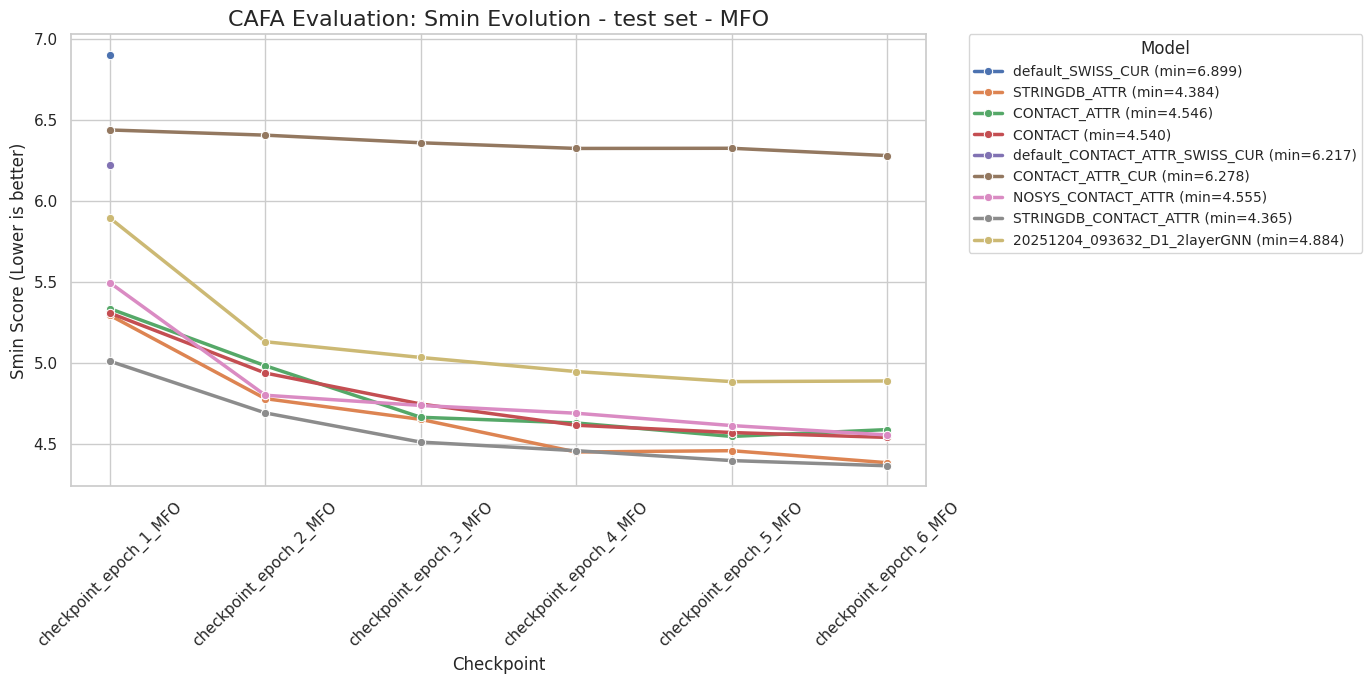

In [7]:
# Load CAFA data for evolution plotting
df_cafa_evo = load_cafa_tsv_data()

if not df_cafa_evo.empty:
    # Filter out 'latest' checkpoints to focus on epochs
    df_cafa_evo = df_cafa_evo[~df_cafa_evo['Checkpoint'].str.contains('latest', case=False, na=False)]
    df_cafa_evo = df_cafa_evo.sort_values(['Model', 'Checkpoint'])

    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")

    # Plot Smin evolution using Seaborn
    sns.lineplot(
        data=df_cafa_evo, 
        x='Checkpoint', 
        y='Smin', 
        hue='Model', 
        marker='o',
        linewidth=2.5
    )

    plt.title(f'CAFA Evaluation: Smin Evolution - {SPLIT} set - {SUBONTOLOGY}', fontsize=16)
    plt.xlabel('Checkpoint', fontsize=12)
    plt.ylabel('Smin Score (Lower is better)', fontsize=12)
    plt.xticks(rotation=45)
    
    # Simplify legend labels and add min Smin value
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        # The label corresponds to the 'Model' name in the dataframe
        # Find the minimum Smin for this model
        min_val = df_cafa_evo.loc[df_cafa_evo['Model'] == label, 'Smin'].min()
        
        short_name = label.split('GNN_')[-1]
        
        if pd.notna(min_val):
            new_labels.append(f"{short_name} (min={min_val:.3f})")
        else:
            new_labels.append(short_name)

    plt.legend(handles, new_labels, title='Model', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No CAFA data available for plotting.")

In [12]:
import pandas as pd
import os
import pickle

# Load a specific beprof_eval_results.pkl file
specific_pkl_path = "/home/atoffano/PFP_layer/results/D1/20251204_093632_D1_2layerGNN/evaluation/val_MFO/beprof-eval/beprof_eval_results.pkl"

if os.path.exists(specific_pkl_path):
    with open(specific_pkl_path, 'rb') as f:
        specific_result = pickle.load(f)
    print("Loaded result keys:", list(specific_result.keys()))
    print("Fmax:", specific_result.get('result_fmax'))
    print("Smin:", specific_result.get('result_smin'))
else:
    print(f"File not found: {specific_pkl_path}")

Loaded result keys: ['ontology', 'recalls', 'precisions', 'icprecisions', 'icrecalls', 'dpprecisions', 'dprecalls', 'result_aupr', 'result_icaupr', 'result_dpaupr', 'ru_values', 'mi_values', 'goic_vector', 'godp_vector', 'result_fmax', 'result_smin', 'result_t']
Fmax: 0.5990208114185497
Smin: 7.336984704036438


In [13]:
specific_result

{'ontology': 'mf',
 'recalls': array([0.        , 0.06930734, 0.11759462, 0.15001255, 0.17754756,
        0.20196602, 0.22018092, 0.23591459, 0.25415753, 0.27120986,
        0.28823344, 0.30422959, 0.3156986 , 0.33100261, 0.3413373 ,
        0.35826909, 0.36625912, 0.37875747, 0.38896363, 0.39724147,
        0.40357049, 0.41235489, 0.42028923, 0.43064362, 0.44167185,
        0.44639784, 0.45249934, 0.4566866 , 0.46171188, 0.46855156,
        0.47366167, 0.47921569, 0.48266825, 0.48702603, 0.49117485,
        0.49620524, 0.49966559, 0.5034933 , 0.50592024, 0.50835977,
        0.5125453 , 0.51589752, 0.5204846 , 0.5245676 , 0.52845767,
        0.53055144, 0.53344003, 0.53617381, 0.53888036, 0.54029932,
        0.54275292, 0.54487586, 0.54769808, 0.55097825, 0.55375867,
        0.55685236, 0.5608478 , 0.56257695, 0.56556587, 0.56866177,
        0.57078553, 0.572989  , 0.5760257 , 0.57957795, 0.58406208,
        0.58720467, 0.59056304, 0.59182436, 0.59514714, 0.59803541,
        0.60050516